In [50]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from db_config import get_database_url
from sqlalchemy import create_engine


In [62]:
engine = create_engine(get_database_url())
#camps_point_id = 6
df = pd.read_sql(
    "SELECT * FROM public.pollen_by_date_time",
    engine
)

df.head()

,fdate,ftime,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-08,00:00:00,2026-07-08,0.0000000009,0.0000000000,1.9842224121,0.1097717285,0.0000190735,0.0000000009,2.0940132141
1,2026-07-08,01:00:00,2026-07-08,0.0000000009,0.0000000000,2.8350830078,0.0478820801,0.0000000000,0.0000000000,2.8829650879
2,2026-07-08,02:00:00,2026-07-08,0.0000000009,0.0000000000,1.1633300781,0.0789489746,0.0000152588,0.0000000009,1.2422943115
3,2026-07-08,03:00:00,2026-07-08,0.0000000009,0.0000000000,1.1064453125,0.0880126953,0.0000076294,0.0000000000,1.1944656372
4,2026-07-08,04:00:00,2026-07-08,0.0000000009,0.0000000000,0.6542358398,0.1577453613,0.0000000000,0.0000000000,0.8119812012


In [63]:
df['fdate'] = pd.to_datetime(df['fdate'], format='%Y-%m-%d')
df['ftime'] = pd.to_datetime(df['ftime'], format='%H:%M:%S').dt.time
df['analysis_time'] = pd.to_datetime(df['analysis_time'], format='%Y-%m-%d')
df.head()

,fdate,ftime,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-08,00:00:00,2026-07-08,0.0000000009,0.0000000000,1.9842224121,0.1097717285,0.0000190735,0.0000000009,2.0940132141
1,2026-07-08,01:00:00,2026-07-08,0.0000000009,0.0000000000,2.8350830078,0.0478820801,0.0000000000,0.0000000000,2.8829650879
2,2026-07-08,02:00:00,2026-07-08,0.0000000009,0.0000000000,1.1633300781,0.0789489746,0.0000152588,0.0000000009,1.2422943115
3,2026-07-08,03:00:00,2026-07-08,0.0000000009,0.0000000000,1.1064453125,0.0880126953,0.0000076294,0.0000000000,1.1944656372
4,2026-07-08,04:00:00,2026-07-08,0.0000000009,0.0000000000,0.6542358398,0.1577453613,0.0000000000,0.0000000000,0.8119812012


In [64]:
df.dtypes

fdate             datetime64[s]
ftime                    object
analysis_time     datetime64[s]
alder_pollen            float64
birch_pollen            float64
grass_pollen            float64
mugwort_pollen          float64
olive_pollen            float64
ragweed_pollen          float64
pollen_total            float64
dtype: object

In [65]:
pd.set_option('display.float_format', '{:.10f}'.format)

In [66]:
df_grouped = df.groupby(['fdate'])[
    ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
].mean()
df_grouped.tail()

,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
fdate,,,,,,,
2026-07-04,0.0000000001,0.0000000000,35.3035125732,0.2684563001,0.0000000000,0.0000000000,35.5719688733
2026-07-05,0.0000000004,0.0000000000,17.0619500478,0.0682776769,0.0000000000,0.0000000000,17.1302277247
2026-07-06,0.0000000006,0.0000000000,22.1471761068,0.2482953072,0.0000000000,0.0000000000,22.3954714139
2026-07-07,0.0000000179,0.0000000000,22.3213761648,0.7326545715,0.0000070731,0.0000000017,23.0540378094
2026-07-08,0.0000000224,0.0014769236,20.6589368184,0.2743790944,0.0000017484,0.0000000001,20.9347945849


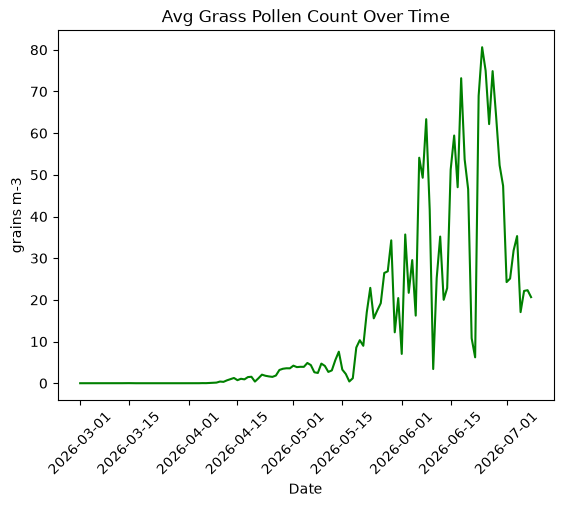

In [67]:
%matplotlib inline

plt.plot(df_grouped['grass_pollen'], color='g')
plt.title("Avg Grass Pollen Count Over Time")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("grains m-3")
plt.axis('tight');

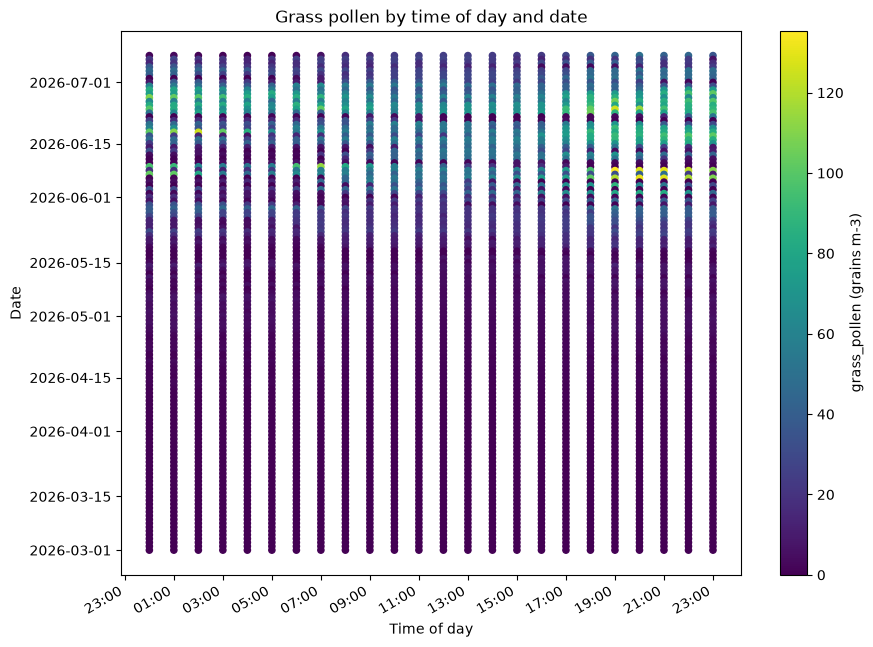

In [68]:
# Scatter plot: x = ftime (time of day), y = fdate (date), color = grass_pollen
import matplotlib.dates as mdates
ftimes = pd.to_datetime(df['ftime'].astype(str), format='%H:%M:%S', errors='coerce')
fdates = pd.to_datetime(df['fdate'])
plt.figure(figsize=(10,8))
sc = plt.scatter(ftimes, fdates, c=df['grass_pollen'], cmap='viridis', s=20)
plt.colorbar(sc, label='grass_pollen (grains m-3)')
plt.xlabel('Time of day')
plt.ylabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()
plt.title('Grass pollen by time of day and date')
plt.show()